In [46]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
from scipy.special import wofz
from scipy.signal import find_peaks
from scipy.ndimage import median_filter
#import numpy.polynomial.polynomial as poly
#from numpy.polynomial import Polynomial
#import scipy.constants as const
#from matplotlib.animation import FuncAnimation, PillowWriter
#from astropy.time import Time
#from IPython.display import HTML

<h2 style="color: #e19edc;"> Antares</h2>

In [47]:
# Rutas de Julio, Agosto y Septiembre del 2026

ruta_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares 6563 julio 22.xlsx"

ruta_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares agosto 26 orden 1.xlsx"

ruta_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares septiembre 6 orden 1.xlsx"

#Datos de Julio, Agosto y Septiembre del 2026

antares_julio = pd.read_excel(ruta_julio, sheet_name="ster 6563 normaliz", usecols=[0,3], header=None, names =["pixel", "flujo normalizado"])

antares_agosto = pd.read_excel(ruta_agosto, sheet_name="ster orden1", usecols=[0, 3], header=None, names =["pixel", "flujo normalizado"])

antares_septiembre = pd.read_excel(ruta_septiembre, sheet_name="ster orden 1", usecols=[0, 3], header=None, names =["pixel", "flujo normalizado"])


<h3 style="color: #e19edc;"> Visualización del perfil de la línea H<sub>&alpha;</sub> en diferentes meses</h3>

In [48]:
print("--- Julio---")
display(antares_julio.head())

--- Julio---


,pixel,flujo normalizado
0,0,0.802719
1,1,0.795175
2,2,0.787987
3,3,0.790366
4,4,0.801433


In [49]:
pixeles_julio = antares_julio["pixel"].values
flujo_julio = antares_julio["flujo normalizado"].values
longitudes_observadas_julio = -3.035260607578e-13 * pixeles_julio**4 + 8.715422792701e-10 * pixeles_julio**3 - 0.0000007942095333894*pixeles_julio**2 + 0.09284696077816 * pixeles_julio + 6506.688414868

<h4 style="color: #e19edc;"> Julio</h4>

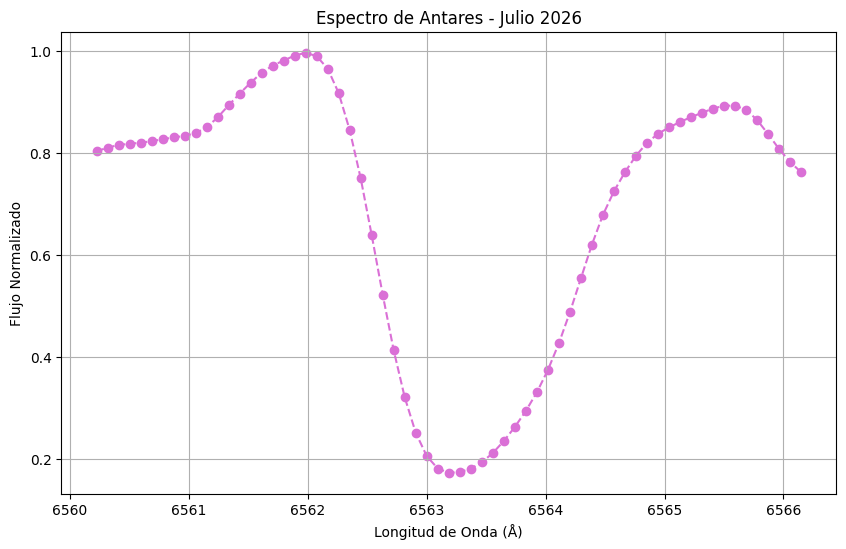

In [112]:
centro_julio = 6563.18533

indices_cercanos_julio = np.where((longitudes_observadas_julio >= centro_julio - 3) & (longitudes_observadas_julio <= centro_julio + 3))[0]


datos_cercanos_julio = pd.DataFrame({'longitud_observada': longitudes_observadas_julio[indices_cercanos_julio], 'flujo_normalizado': flujo_julio[indices_cercanos_julio]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_julio["longitud_observada"], datos_cercanos_julio["flujo_normalizado"], '--', color = "orchid")
plt.scatter(datos_cercanos_julio["longitud_observada"], datos_cercanos_julio["flujo_normalizado"], color = "orchid")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Julio 2026")
plt.grid(True)
plt.show()


<h4 style="color: #e19edc;"> Agosto </h4>

In [89]:
print("--- Agosto---")
display(antares_agosto.head())

--- Agosto---


,pixel,flujo normalizado
0,0,1.098379
1,1,1.141431
2,2,1.158189
3,3,1.144393
4,4,1.117359


In [52]:
pixeles_agosto = antares_agosto["pixel"].values
flujo_agosto = antares_agosto["flujo normalizado"].values
longitudes_observadas_agosto = 1.39394098683175e-18 * pixeles_agosto**6 - 6.58044383788171E-15*pixeles_agosto**5 + 1.16354508506345E-11*pixeles_agosto**4 - 9.29864698195214E-09*pixeles_agosto**3 + 3.02469198127472E-06*pixeles_agosto**2 + 0.0924365570558958*pixeles_agosto + 6492.49282015586

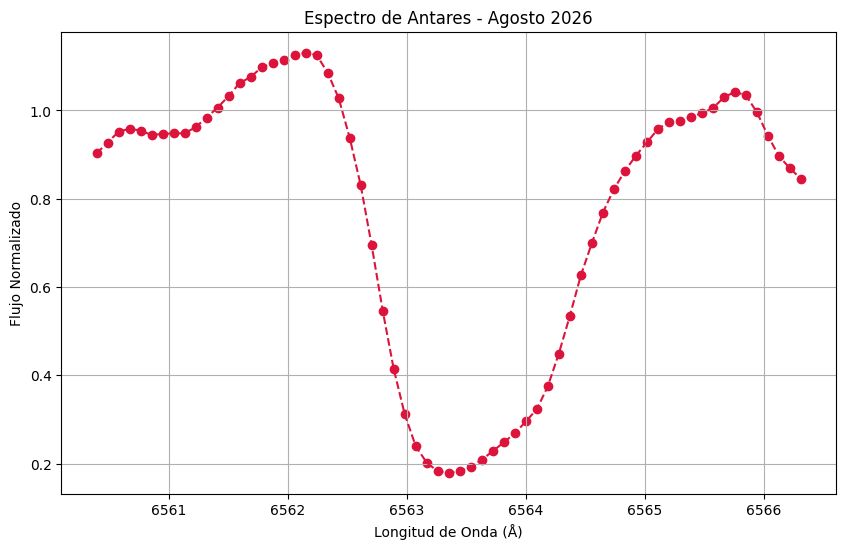

In [113]:
centro_agosto = 6563.35423

indices_cercanos_agosto = np.where((longitudes_observadas_agosto >= centro_agosto - 3) & (longitudes_observadas_agosto <= centro_agosto + 3))[0]


datos_cercanos_agosto = pd.DataFrame({'longitud_observada': longitudes_observadas_agosto[indices_cercanos_agosto], 'flujo_normalizado': flujo_agosto[indices_cercanos_agosto]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_agosto["longitud_observada"], datos_cercanos_agosto["flujo_normalizado"], '--', color = "crimson")
plt.scatter(datos_cercanos_agosto["longitud_observada"], datos_cercanos_agosto["flujo_normalizado"], color = "crimson")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Agosto 2026")
plt.grid(True)
plt.show()

<h4 style="color: #e19edc;"> Septiembre</h4>

In [91]:
print("--- Septiembre---")
display(antares_septiembre.head())

--- Septiembre---


,pixel,flujo normalizado
0,0,0.991728
1,1,0.991792
2,2,0.962534
3,3,0.892629
4,4,0.817738


In [56]:
pixeles_septiembre = antares_septiembre["pixel"].values
flujo_septiembre = antares_septiembre["flujo normalizado"].values
longitudes_observadas_septiembre = -1.179402526298E-13*pixeles_septiembre**4 + 4.020234124929E-10*pixeles_septiembre**3 - 0.0000004743246209058*pixeles_septiembre**2 + 0.09282817058921*pixeles_septiembre + 6490.328062797

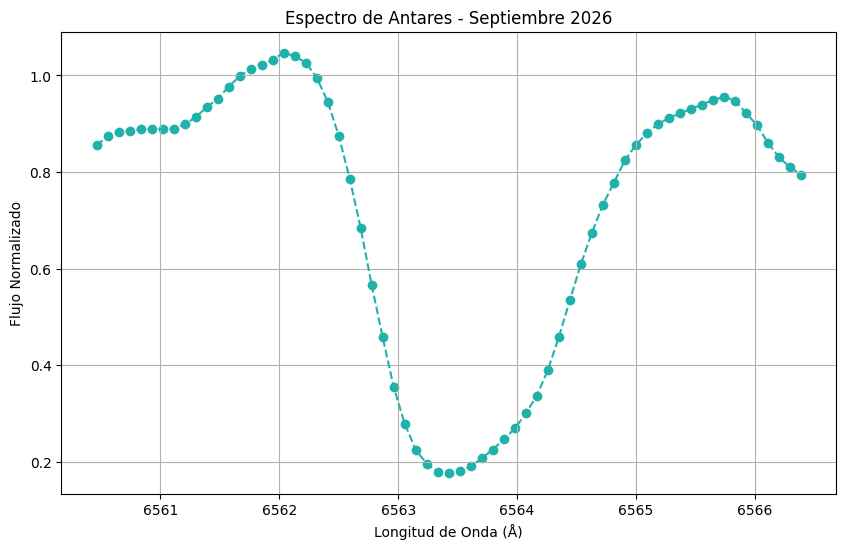

In [114]:
centro_septiembre = 6563.42597

indices_cercanos_septiembre = np.where((longitudes_observadas_septiembre >= centro_septiembre - 3) & (longitudes_observadas_septiembre <= centro_septiembre + 3))[0]


datos_cercanos_septiembre = pd.DataFrame({'longitud_observada': longitudes_observadas_septiembre[indices_cercanos_septiembre], 'flujo_normalizado': flujo_septiembre[indices_cercanos_septiembre]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_septiembre["longitud_observada"], datos_cercanos_septiembre["flujo_normalizado"], '--', color = "lightseagreen")
plt.scatter(datos_cercanos_septiembre["longitud_observada"], datos_cercanos_septiembre["flujo_normalizado"], color = "lightseagreen")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Septiembre 2026")
plt.grid(True)
plt.show()

<h3 style="color: #e19edc;"> Obtención del perfil de absorción y emisión de la línea H<sub>&alpha;</sub></h3>

<h4 style="color: #e19edc;"> Sin tener en cuenta las posibles mezclas de las líneas metálicas</h4>

In [12]:
#MODELO DE AJUSTE

# Usamos Voigt para el valle ya que permite tener en cuenta las asimetrías del perfil de la línea de absorción

def construccion_del_modelo():
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    return continuo + em_azul + valle_abs

def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox):
    p = modelo.make_params()

    borde = np.r_[flujo[:10], flujo[-10:]]
    p["cont_c"].set(value=np.median(borde), min=0, max=2)

    izquierda = longitud_onda < centro_aprox

    # Emisión azul
    i_azul = np.argmax(flujo[izquierda])
    p["em_azul_center"].set(value=longitud_onda[izquierda][i_azul],
                             min=longitud_onda.min(), max=centro_aprox)
    p["em_azul_amplitude"].set(value=1.0, min=0)
    p["em_azul_sigma"].set(value=0.4, min=0.05, max=2)

    # Absorción central
    i_min = np.argmin(flujo)
    p["valle_abs_center"].set(value=longitud_onda[i_min], min=centro_aprox - 1, max=centro_aprox + 1)
    p["valle_abs_amplitude"].set(value=-(np.median(borde) - flujo[i_min]) * 1.5, max=0)
    p["valle_abs_sigma"].set(value=0.3, min=0.03, max=1.2)
    p["valle_abs_gamma"].set(value=0.2, min=0, max=1.2, vary=True)

    return p


In [13]:
# DESCOMPOSICIÓN

def fit_y_decomposición(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    modelo = construccion_del_modelo()
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox)
    fit = modelo.fit(flujo, parametros, x=longitud_onda)

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]  
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(wave=longitud_onda, flux=flujo, fit=fit, comps=comps, perfil_emision=perfil_emision, perfil_absorcion=perfil_absorcion,
                residuo=residuo)

def resumen_fisico(fit):
    p = fit.params
    print("\n--- Resumen del ajuste ---")
    for comp, label in [("em_azul", "Emisión azul")]:
        c = p[f"{comp}_center"].value
        fwhm = p[f"{comp}_fwhm"].value
        amp = p[f"{comp}_height"].value
        print(f"{label:14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   altura={amp:5.3f}")

    c = p["valle_abs_center"].value
    fwhm = p["valle_abs_fwhm"].value
    profundidad = p["valle_abs_height"].value
    print(f"{'Absorción central':14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   profundidad={profundidad:5.3f}")

    print(f"\nContinuo local ajustado: {p['cont_c'].value:.3f}")
    print(f"Chi-cuadrado reducido:   {fit.redchi:.3e}")

In [16]:
# GRÁFICA

def visualizacion_decomposicion(res, titulo="Descomposición H-alpha"):
    longitud_observada, flujo, fit = res["wave"], res["flux"], res["fit"]
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_observada, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_observada, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_observada, res["perfil_emision"], "--", color="turquoise", lw=1.5,
            label="Perfil de emisión (sin absorción)")
    ax.plot(longitud_observada, res["perfil_absorcion"], "--", color="deepskyblue", lw=1.5,
            label="Perfil de absorción (sin emisión)")
    ax.axhline(res["comps"]["cont_"][0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_observada, res["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.135 Å   FWHM= 0.89 Å   altura=0.325
Absorción central: centro= 6563.304 Å   FWHM= 1.65 Å   profundidad=-0.720

Continuo local ajustado: 0.839
Chi-cuadrado reducido:   1.199e-03


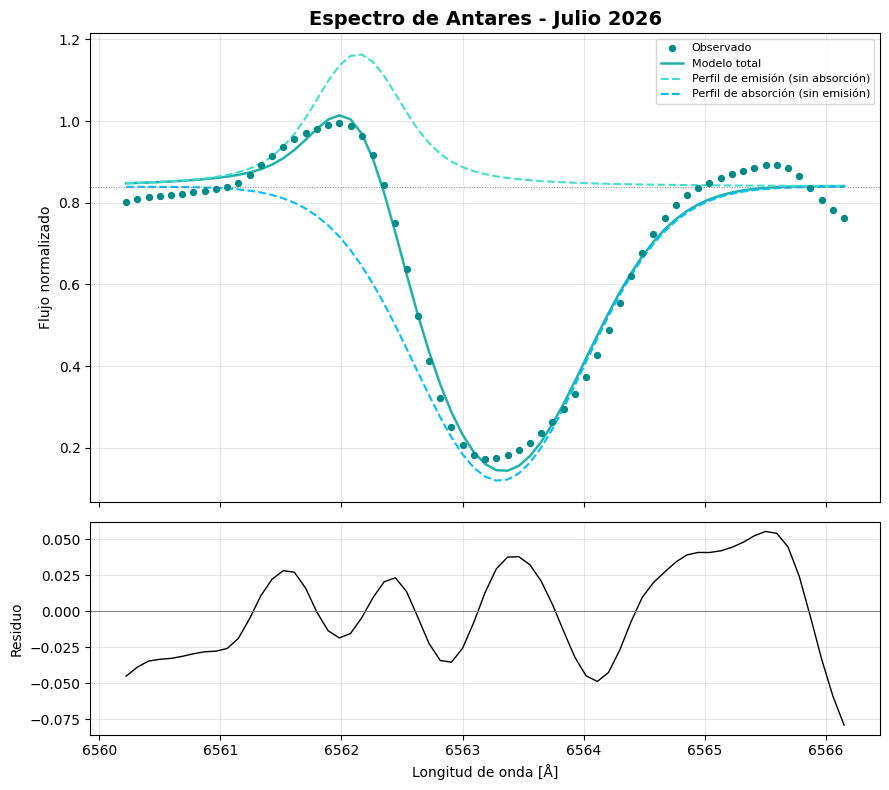

In [17]:
res = fit_y_decomposición(datos_cercanos_julio, centro_julio, "longitud_observada", "flujo_normalizado")
resumen_fisico(res["fit"])
visualizacion_decomposicion(res, titulo="Espectro de Antares - Julio 2026")


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.289 Å   FWHM= 0.89 Å   altura=0.383
Absorción central: centro= 6563.465 Å   FWHM= 1.70 Å   profundidad=-0.855

Continuo local ajustado: 0.962
Chi-cuadrado reducido:   2.294e-03


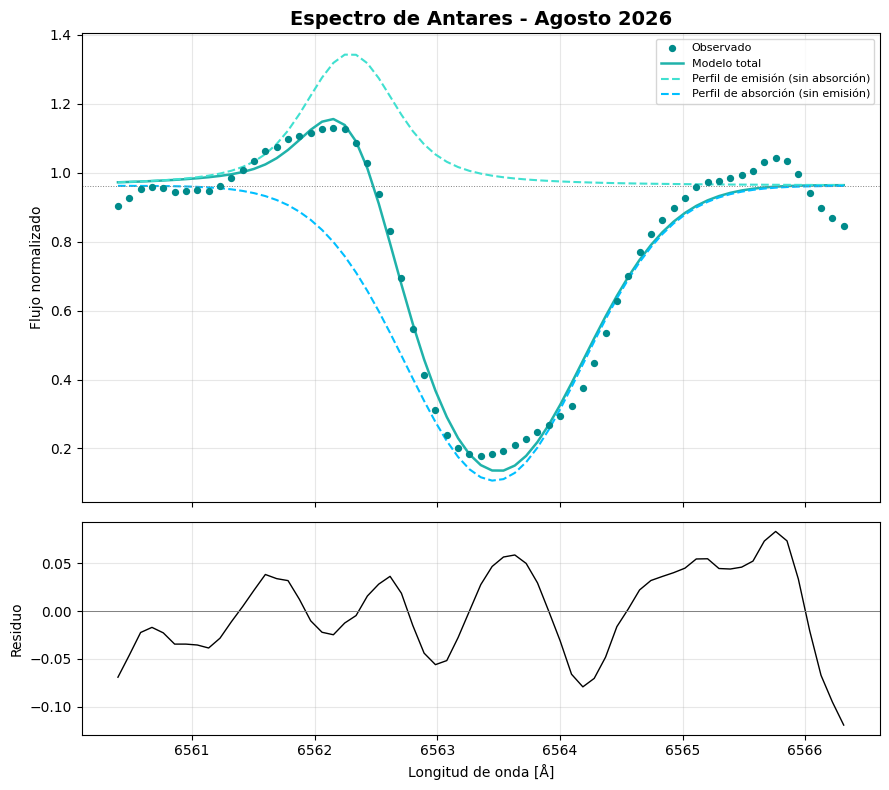

In [18]:
res_a = fit_y_decomposición(datos_cercanos_agosto, centro_agosto, "longitud_observada", "flujo_normalizado")
resumen_fisico(res_a["fit"])
visualizacion_decomposicion(res_a, titulo="Espectro de Antares - Agosto 2026")


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.259 Å   FWHM= 0.92 Å   altura=0.297
Absorción central: centro= 6563.515 Å   FWHM= 1.68 Å   profundidad=-0.777

Continuo local ajustado: 0.895
Chi-cuadrado reducido:   1.629e-03


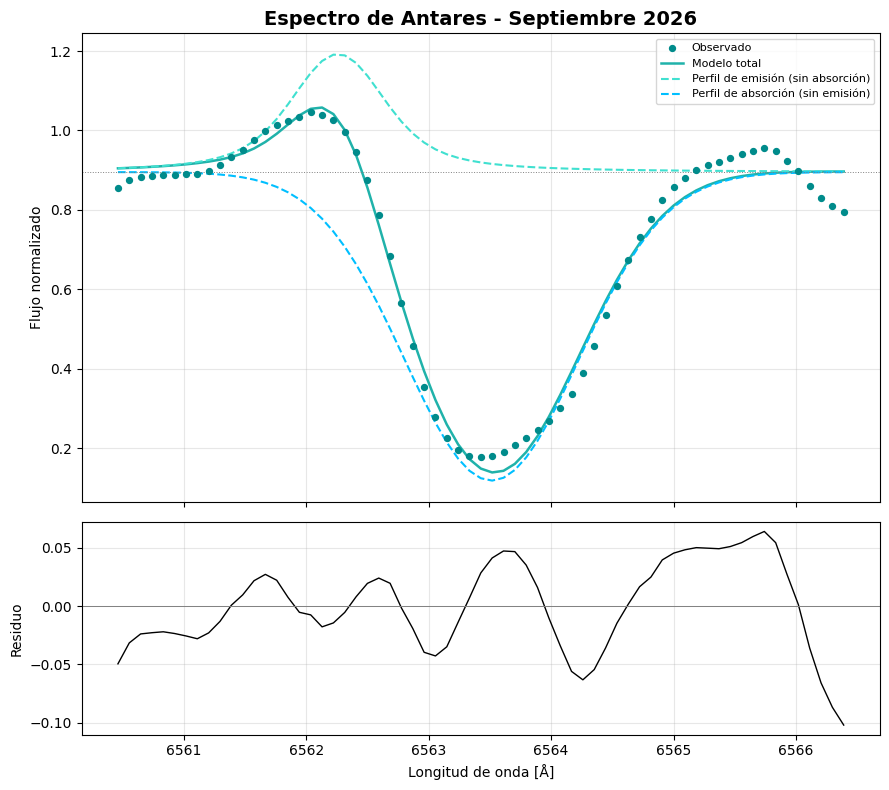

In [19]:
res_s = fit_y_decomposición(datos_cercanos_septiembre, centro_septiembre, "longitud_observada", "flujo_normalizado")
resumen_fisico(res_s["fit"])
visualizacion_decomposicion(res_s, titulo="Espectro de Antares - Septiembre 2026")

<h4 style="color: #e19edc;"> Teniendo en cuenta las posibles mezclas con las líneas de absorción</h4>

In [93]:
c_kms_s = 299792.458

def efecto_doppler(longitud_lab, velocidad_kms):
    return longitud_lab * (1 + velocidad_kms / c_kms_s)


def profundidad_interpolada(teff, t_ref=(3500, 4250), prof_ref=(0.55, 0.63)):
    return float(np.interp(teff, t_ref, prof_ref))


def amplitud_desde_profundidad(profundidad, continuo_local, sigma, gamma):
    z = 1j * gamma / (sigma * np.sqrt(2))
    pico_unitario = wofz(z).real / (sigma * np.sqrt(2 * np.pi))
    return -profundidad * continuo_local / pico_unitario

In [ ]:
def estimar_continuo_local(longitud_onda, flujo, centro_aprox, semiancho_exclusion=3.0, percentil=92, n_iter=10, lineas_metalicas=None):
    fuera_de_linea = np.abs(longitud_onda - centro_aprox) > semiancho_exclusion

    if lineas_metalicas:
        for linea in lineas_metalicas:
            fuera_de_linea &= np.abs(longitud_onda - linea["centro"]) > 0.6

    valores = flujo[fuera_de_linea]

    if valores.size == 0:
        raise ValueError("No quedan puntos fuera de línea para estimar el continuo.")

    mascara = np.ones_like(valores, dtype=bool)
    for _ in range(n_iter):
        p_alto = np.percentile(valores[mascara], percentil)
        mad = np.median(np.abs(valores[mascara] - np.median(valores[mascara]))) * 1.4826
        nueva_mascara = valores < (p_alto + 3 * mad)
        if nueva_mascara.sum() < 5:
            break
        mascara = nueva_mascara

    continuo = float(np.percentile(valores[mascara], percentil))
    dispersion = float(np.std(valores[mascara][valores[mascara] >= np.percentile(valores[mascara], percentil - 10)]))

    return continuo, dispersion

In [ ]:
#MODELO DE AJUSTE

def construccion_del_modelo(lineas_metalicas=None):
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    modelo = continuo + em_azul + valle_abs

    if lineas_metalicas:
        for linea in lineas_metalicas:
            modelo += VoigtModel(prefix=f"{linea['nombre']}_")

    return modelo

In [ ]:
def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox, 
                          longitud_onda_continuo=None, flujo_continuo=None,
                          lineas_metalicas=None, teff=3660):
    p = modelo.make_params()

    #Continuo

    lo_cont = longitud_onda_continuo if longitud_onda_continuo is not None else longitud_onda
    fl_cont = flujo_continuo if flujo_continuo is not None else flujo

    continuo_local, disp_continuo = estimar_continuo_local(lo_cont, fl_cont, centro_aprox, lineas_metalicas=lineas_metalicas)

    margen = max(0.05, 4 * disp_continuo)
    p["cont_c"].set(value=continuo_local, min=continuo_local - margen, max=continuo_local + margen)

    flujo_suave = median_filter(flujo, size=5)
    izquierda = (longitud_onda < (centro_aprox - 0.2)) & (longitud_onda > (centro_aprox - 2.5))

    # Emisión Azul
    if np.any(izquierda):
        x_izq = longitud_onda[izquierda]
        y_izq = flujo_suave[izquierda]
        picos, props = find_peaks(y_izq, prominence=0.01)

        if len(picos) > 0:
            idx_mejor = picos[np.argmax(props["prominences"])]
            c_azul_inicio = x_izq[idx_mejor]
            amp_azul_inicio = max(0.05, flujo[izquierda][idx_mejor] - continuo_local)
        else:
            i_azul = np.argmax(y_izq)
            c_azul_inicio = x_izq[i_azul]
            amp_azul_inicio = max(0.05, flujo[izquierda][i_azul] - continuo_local)
    else:
        c_azul_inicio = centro_aprox - 0.8
        amp_azul_inicio = 0.2

    p["em_azul_center"].set(value=c_azul_inicio, min=centro_aprox - 2.8, max=centro_aprox - 0.15)
    p["em_azul_amplitude"].set(value=amp_azul_inicio * 0.5, min=0, max=amp_azul_inicio * 5.0)
    p["em_azul_sigma"].set(value=0.30, min=0.05, max=1.2)
    p["em_azul_gamma"].set(value=0.15, min=0.0, max=1.0, vary=True)

    # Absorción central (Halpha)

    ventana_centro = np.abs(longitud_onda - centro_aprox) < 1.8
    if np.any(ventana_centro):

        idx_local = np.argmin(flujo_suave[ventana_centro])

        c_abs_inicio = longitud_onda[ventana_centro][idx_local]

    else:
        
        c_abs_inicio = centro_aprox

    i_min = np.argmin(np.abs(longitud_onda - c_abs_inicio))

    p["valle_abs_center"].set(value=c_abs_inicio, min=centro_aprox - 1.0, max=centro_aprox + 1.0)

    prof_abs_est = max(0.1, continuo_local - flujo[i_min])
    amp_abs_inicio = -prof_abs_est * 0.8
    p["valle_abs_amplitude"].set(value=amp_abs_inicio, min=-5.0, max=0)
    p["valle_abs_sigma"].set(value=0.25, min=0.05, max=1.0)
    p["valle_abs_gamma"].set(value=0.15, min=0, max=0.8, vary=True)

    # Líneas metálicas

    if lineas_metalicas:
        for linea in lineas_metalicas:
            pref = f"{linea['nombre']}_"
            c0_lab = linea["centro"]

            v = linea.get("velocidad", 0.0)
            c0_obs = efecto_doppler(c0_lab, v)

            margen_v = max(0.1, linea.get("incertidumbre_v", 3.0)) 
            margen_aa = c0_lab * margen_v / c_kms_s
            
            p[f"{pref}center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)

            sigma0 = linea.get("sigma_inicial", 0.12)
            gamma0 = linea.get("gamma_inicial", 0.05)
            p[f"{pref}sigma"].set(value=sigma0, min=0.02, max=0.4)
            p[f"{pref}gamma"].set(value=gamma0, min=0, max=0.3, vary=True)

            prof = linea.get("profundidad")  
            if prof is None:
                prof = profundidad_interpolada(
                    teff, t_ref=linea.get("t_ref", (3500, 4250)), prof_ref=linea.get("prof_ref", (0.55, 0.63)))
            
            amp0 = amplitud_desde_profundidad(prof, continuo_local, sigma0, gamma0)
            
            min_amp = min(amp0 * 3.0, amp0 * 0.1)
            p[f"{pref}amplitude"].set(value=amp0, min=min_amp, max=0)

    return p

In [ ]:
# DESCOMPOSICIÓN DE "PERFILES"

def fit_y_decomposicion(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado, datos_completos=None, lineas_metalicas=None, teff=3660):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    # Estimación del continuo

    if datos_completos is not None:

        longitud_onda_continuo = datos_completos[longitud_observada].to_numpy()

        flujo_continuo = datos_completos[flujo_normalizado].to_numpy()

    else:

        longitud_onda_continuo = longitud_onda
        
        flujo_continuo = flujo

    modelo = construccion_del_modelo(lineas_metalicas)
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox, longitud_onda_continuo=longitud_onda_continuo,
                                       flujo_continuo=flujo_continuo, lineas_metalicas=lineas_metalicas, teff=teff)
    
    fit = modelo.fit(flujo, parametros, x=longitud_onda, nan_policy='omit')

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(longitud_onda=longitud_onda, flujo=flujo, fit=fit, comps=comps, 
                perfil_emision=perfil_emision, perfil_absorcion=perfil_absorcion, residuo=residuo)

In [119]:
# VISUALIZACIÓN

def visualizacion_con_metalica(res_metal, lineas_metalicas, mes, titulo,):
    longitud_onda, flujo, fit = res_metal["longitud_onda"], res_metal["flujo"], res_metal["fit"]
    comps = res_metal["comps"]
    continuo = comps["cont_"]

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_onda, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_onda, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_onda, res_metal["perfil_emision"], "--", color="turquoise", lw=1.3,
            label="Perfil de emisión")
    ax.plot(longitud_onda, res_metal["perfil_absorcion"], "--", color="deepskyblue", lw=1.3,
            label=r"Perfil de absorción $H_\alpha$")

    for linea in lineas_metalicas:
        pref = f"{linea['nombre']}_"
        perfil_metal = continuo + comps[pref]
        ax.plot(longitud_onda, perfil_metal, "-.", color="purple", lw=1.3,
                label=f"Componente {linea['nombre']}")
        ax.axvline(fit.params[f"{pref}center"].value, color="orchid",
                   lw=0.7, ls=":", alpha=0.5)

    ax.axhline(continuo[0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_onda, res_metal["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fr"Graficas 2025 y 2026\halpha_{mes.lower()}_cobalto.png", dpi=150)
    plt.show()

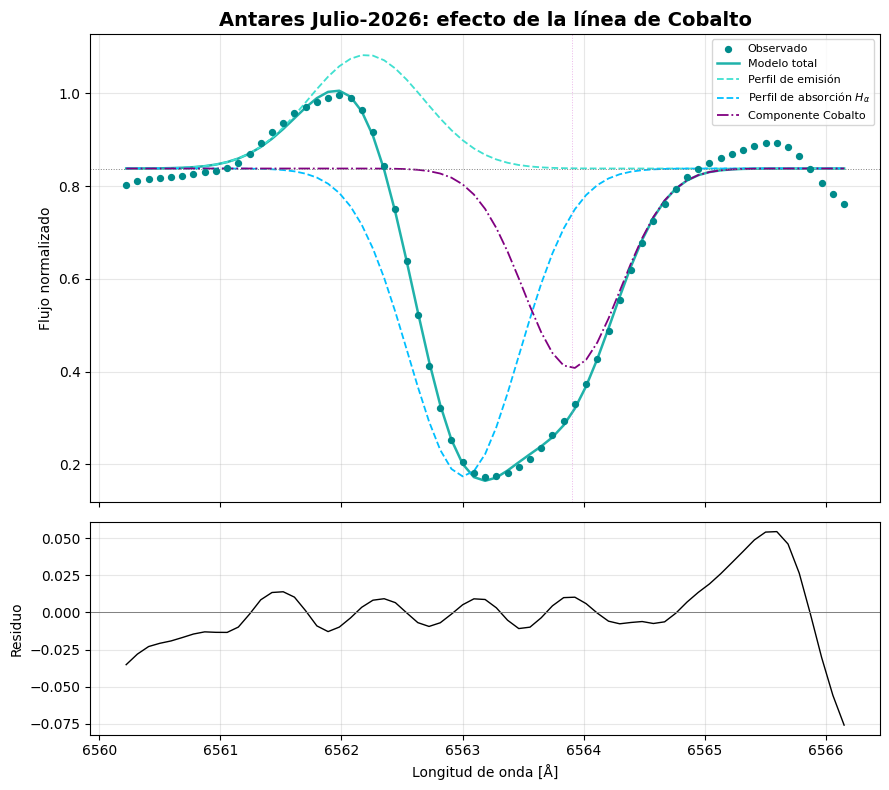

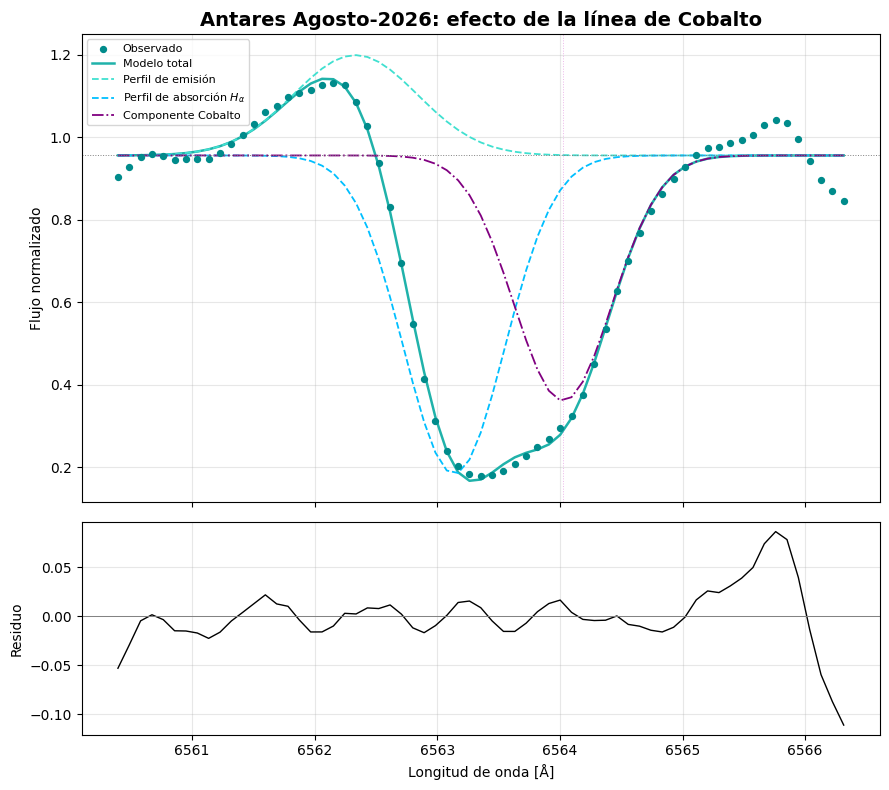

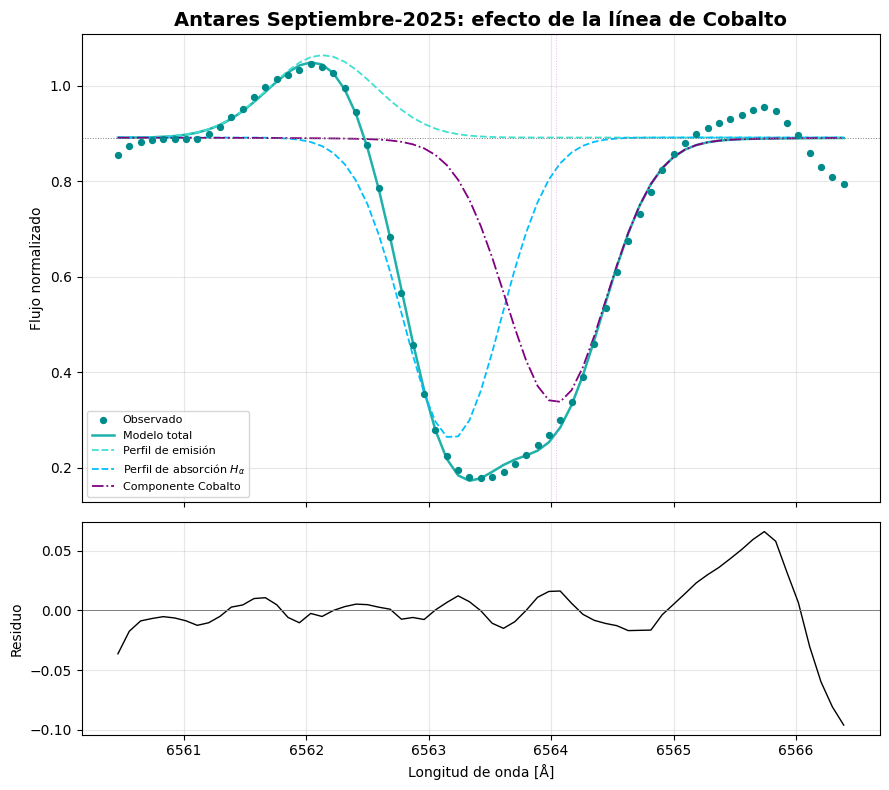

In [128]:
#Margen para el continuo
margen_continuo = 15  # Å

def construir_ventana(longitudes, flujo, centro, margen):
    idx = np.where((longitudes >= centro - margen) & (longitudes <= centro + margen))[0]
    return pd.DataFrame({'longitud_observada': longitudes[idx], 'flujo_normalizado': flujo[idx]})

datos_completos_julio = construir_ventana(longitudes_observadas_julio, flujo_julio, centro_julio, margen_continuo)
datos_completos_agosto = construir_ventana(longitudes_observadas_agosto, flujo_agosto, centro_agosto, margen_continuo)
datos_completos_septiembre = construir_ventana(longitudes_observadas_septiembre, flujo_septiembre, centro_septiembre, margen_continuo)

# Datos completos
archivos = [
    {
        "fecha": "Julio-2026",
        "datos": datos_cercanos_julio,
        "datos_completos": datos_completos_julio,
        "centro_aprox": centro_julio,
        "velocidad_metalica": 22.1,   #km/s
        "incertidumbre_v": 0.9,
    },
    {
        "fecha": "Agosto-2026",
        "datos": datos_cercanos_agosto,
        "datos_completos": datos_completos_agosto,
        "centro_aprox": centro_agosto,
        "velocidad_metalica": 28.3,  # km/s 
        "incertidumbre_v": 0.4,
    },
    {
        "fecha": "Septiembre-2025",
        "datos": datos_cercanos_septiembre,
        "datos_completos": datos_completos_septiembre,
        "centro_aprox": centro_septiembre,
        "velocidad_metalica": 28.4,  # km/s
        "incertidumbre_v": 0.9,
    },
]

resultados = {}  

for archivo in archivos:
    
    fecha = archivo["fecha"]

    lineas_metalicas = [
        {
            "nombre": "Cobalto",
            "centro": 6563.397,
            "ion": "Co I",
            "velocidad": archivo["velocidad_metalica"],
            "incertidumbre_v": archivo["incertidumbre_v"],
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }
    ]

    res = fit_y_decomposicion(archivo["datos"], archivo["centro_aprox"],
                               "longitud_observada", "flujo_normalizado",
                               datos_completos=archivo["datos_completos"],
                               lineas_metalicas=lineas_metalicas, teff=3660)

    resultados[fecha] = res

    visualizacion_con_metalica(res, lineas_metalicas, fecha,
                                titulo=f"Antares {fecha}: efecto de la línea de Cobalto")

<h3 style="color: #e19edc;"> Obtención de los parámetros del ajuste de H<sub>&alpha;</sub></h3>

In [17]:
h_alpha_natural = 6562.812 #Amstrongs
cobalto_natural = 6563.397 #Amstrongs

resultados_perfiles_halpha_y_cobalto = []

for fecha, res in resultados.items():
    p = res["fit"].params
    comps = res["comps"]
    longitud_onda = res["longitud_onda"]
    continuo = comps["cont_"]
    
    # 1. PERFIL DE EMISIÓN AZUL

    c_em = p["em_azul_center"].value
    fwhm_em = p["em_azul_fwhm"].value
    amp_em = p["em_azul_height"].value 

    # Efecto Doppler (Corrimiento)
    z_em = (c_em - h_alpha_natural) / h_alpha_natural
    v_em = z_em * c_kms_s
    
    # Ancho equivalente de emisión
    perfil_em_puro = comps["em_azul_"]
    ew_em = np.trapezoid(perfil_em_puro / continuo, longitud_onda)
    
    resultados_perfiles_halpha_y_cobalto.append({
        "Época": fecha,
        "Componente": "Emisión Azul Hα",
        "Centro [Å]": round(c_em, 3),
        "z": round(z_em, 6),
        "Velocidad [km/s]": round(v_em, 4),
        "Profundidad / Altura": round(amp_em, 4),
        "FWHM [Å]": round(fwhm_em, 3),
        "EW [Å]": round(ew_em, 4)
    })
    
    # 2. PERFIL DE ABSORCIÓN H_ALPHA
    
    c_abs = p["valle_abs_center"].value
    fwhm_abs = p["valle_abs_fwhm"].value
    prof_abs = abs(p["valle_abs_height"].value) 

    # Efecto Doppler (Corrimiento)
    z_abs = (c_abs - h_alpha_natural) / h_alpha_natural
    v_abs = z_abs * c_kms_s
    
    # Ancho equivalente de absorción
    perfil_abs_puro = comps["valle_abs_"]
    ew_abs = np.trapezoid(abs(perfil_abs_puro) / continuo, longitud_onda)
    
    resultados_perfiles_halpha_y_cobalto.append({
        "Época": fecha,
        "Componente": "Absorción Hα",
        "Centro [Å]": round(c_abs, 3),
        "z": round(z_abs, 6),
        "Velocidad [km/s]": round(v_abs, 4),
        "Profundidad / Altura": round(prof_abs, 4),
        "FWHM [Å]": round(fwhm_abs, 3),
        "EW [Å]": round(ew_abs, 4)
    })

    # 3. LÍNEA DE COBALTO

    c_co = p["Cobalto_center"].value
    fwhm_co = p["Cobalto_fwhm"].value
    prof_co = abs(p["Cobalto_height"].value)

    #Efecto Doopler (Corrimiento)
    z_co = (c_co - cobalto_natural) / cobalto_natural
    v_co = z_co * c_kms_s

    # Ancho equivalente de absorción
    perfil_co_puro = comps["Cobalto_"]
    ew_co = np.trapezoid(abs(perfil_co_puro) / continuo, longitud_onda)

    resultados_perfiles_halpha_y_cobalto.append({
            "Época": fecha,
            "Componente": "Absorción Cobalto",
            "Centro [Å]": round(c_co, 3),
            "z": round(z_co, 6),
            "Velocidad [km/s]": round(v_co, 4),
            "Profundidad / Altura": round(prof_co, 4),
            "FWHM [Å]": round(fwhm_co, 3),
            "EW [Å]": round(ew_co, 4)
        })



tabla_resultados = pd.DataFrame(resultados_perfiles_halpha_y_cobalto)
display(tabla_resultados)

,Época,Componente,Centro [Å],z,Velocidad [km/s],Profundidad / Altura,FWHM [Å],EW [Å]
0,Julio-2026,Emisión Azul Hα,6562.231,-0.000089,-26.5631,0.3692,1.067,0.5820
1,Julio-2026,Absorción Hα,6563.001,0.000029,8.6420,0.7040,1.301,1.2355
2,Julio-2026,Absorción Cobalto,6563.901,0.000077,23.0000,0.3432,0.925,0.4043
3,Agosto-2026,Emisión Azul Hα,6562.453,-0.000055,-16.4071,0.6014,1.273,0.9461
4,Agosto-2026,Absorción Hα,6563.068,0.000039,11.7029,1.0330,1.375,1.8256
5,Agosto-2026,Absorción Cobalto,6564.025,0.000096,28.7000,0.4175,0.875,0.3948
6,Septiembre-2025,Emisión Azul Hα,6562.469,-0.000052,-15.6611,0.8374,1.313,1.4598
7,Septiembre-2025,Absorción Hα,6562.948,0.000021,6.2016,1.0973,1.627,2.3234
8,Septiembre-2025,Absorción Cobalto,6564.038,0.000098,29.3000,0.3597,0.942,0.3952


In [19]:
tabla_resultados.to_excel(fr"Parámetros para análisis de Antares\resultados perfiles halpha 2025 y 2026.xlsx", index=False)


<h3 style="color: #e19edc;"> Verificación de la profundidad de las líneas de absorción metálicas</sub></h3>
<h4 style="color: #e19edc;"> Hierro I (Fe I) con Cobalto (Co I)</sub></h4>

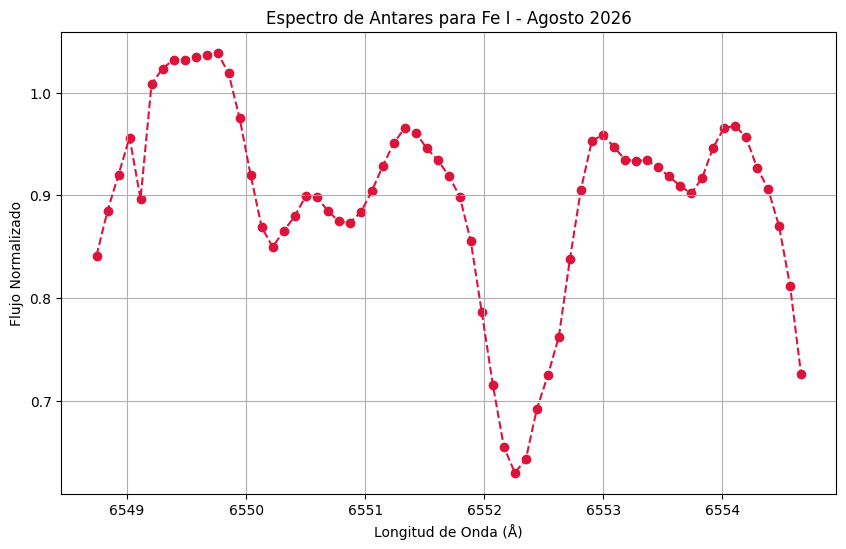

In [27]:
centro_fe = 6551.6767

indices_cercanos_agosto_fe = np.where((longitudes_observadas_agosto >= centro_fe - 3) & (longitudes_observadas_agosto <= centro_fe + 3))[0]


datos_cercanos_agosto_fe = pd.DataFrame({'longitud_observada': longitudes_observadas_agosto[indices_cercanos_agosto_fe], 'flujo_normalizado': flujo_agosto[indices_cercanos_agosto_fe]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_agosto_fe["longitud_observada"], datos_cercanos_agosto_fe["flujo_normalizado"], '--', color = "crimson")
plt.scatter(datos_cercanos_agosto_fe["longitud_observada"], datos_cercanos_agosto_fe["flujo_normalizado"], color = "crimson")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares para Fe I - Agosto 2026")
plt.grid(True)
plt.show()

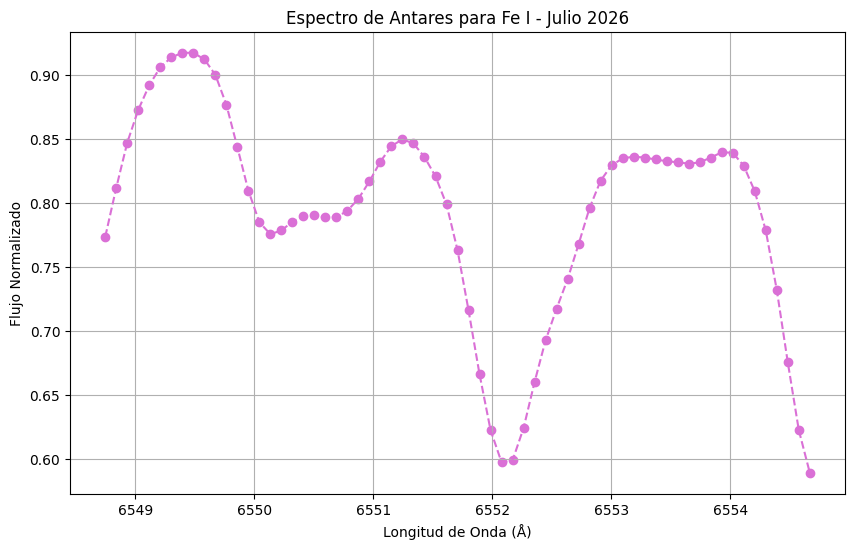

In [28]:
indices_cercanos_julio_fe = np.where((longitudes_observadas_julio >= centro_fe - 3) & (longitudes_observadas_julio <= centro_fe + 3))[0]


datos_cercanos_julio_fe = pd.DataFrame({'longitud_observada': longitudes_observadas_julio[indices_cercanos_julio_fe], 'flujo_normalizado': flujo_julio[indices_cercanos_julio_fe]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_julio_fe["longitud_observada"], datos_cercanos_julio_fe["flujo_normalizado"], '--', color = "orchid")
plt.scatter(datos_cercanos_julio_fe["longitud_observada"], datos_cercanos_julio_fe["flujo_normalizado"], color = "orchid")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares para Fe I - Julio 2026")
plt.grid(True)
plt.show()

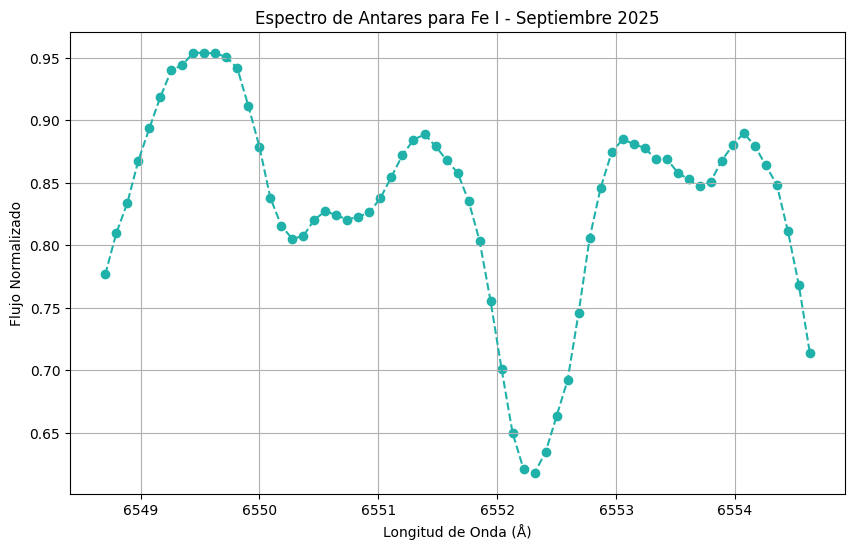

In [29]:
indices_cercanos_septiembre_fe = np.where((longitudes_observadas_septiembre >= centro_fe - 3) & (longitudes_observadas_septiembre <= centro_fe + 3))[0]


datos_cercanos_septiembre_fe = pd.DataFrame({'longitud_observada': longitudes_observadas_septiembre[indices_cercanos_septiembre_fe], 'flujo_normalizado': flujo_septiembre[indices_cercanos_septiembre_fe]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_septiembre_fe["longitud_observada"], datos_cercanos_septiembre_fe["flujo_normalizado"], '--', color = "lightseagreen")
plt.scatter(datos_cercanos_septiembre_fe["longitud_observada"], datos_cercanos_septiembre_fe["flujo_normalizado"], color = "lightseagreen")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares para Fe I - Septiembre 2025")
plt.grid(True)
plt.show()

In [30]:
def construccion_modelo_fe(nombre="fe1"):
    continuo = ConstantModel(prefix="cont_")
    linea_fe = VoigtModel(prefix=f"{nombre}_")
    return continuo + linea_fe


def encontrar_parametros_fe(modelo, flujo, centro_lab, velocidad, incertidumbre_v, sigma_instrumental=None, gamma_instrumental=None, nombre="fe1"):
    p = modelo.make_params()

    # Continuo local
    borde = np.r_[flujo[:5], flujo[-5:]]
    continuo_local = float(np.median(borde))
    p["cont_c"].set(value=continuo_local, min=0, max=2)

    c0_obs = efecto_doppler(centro_lab, velocidad)
    margen_aa = centro_lab * incertidumbre_v / c_kms_s
    p[f"{nombre}_center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)


    if sigma_instrumental is not None:
        p[f"{nombre}_sigma"].set(value=sigma_instrumental, vary=False)
    else:
        p[f"{nombre}_sigma"].set(value=0.12, min=0.02, max=0.4)

    if gamma_instrumental is not None:
        p[f"{nombre}_gamma"].set(value=gamma_instrumental, vary=False)
    else:
        p[f"{nombre}_gamma"].set(value=0.05, min=0, max=0.3)

    i_min = np.argmin(flujo)
    amp0 = -(continuo_local - flujo[i_min]) * 1.2
    p[f"{nombre}_amplitude"].set(value=amp0, min=amp0 * 3, max=0)

    return p

In [31]:
def fit_fe1(datos_fe, longitud_observada, flujo_normalizado, centro_lab, velocidad, incertidumbre_v, sigma_instrumental=None, gamma_instrumental=None, pesos=None, nombre="fe1"):

    longitud_onda = datos_fe[longitud_observada].to_numpy()
    flujo = datos_fe[flujo_normalizado].to_numpy()

    modelo = construccion_modelo_fe(nombre)
    parametros = encontrar_parametros_fe(modelo, flujo, centro_lab, velocidad, incertidumbre_v,sigma_instrumental, gamma_instrumental,nombre)

    kwargs_fit = dict(x=longitud_onda)
    if pesos is not None:
        kwargs_fit["weights"] = pesos

    fit = modelo.fit(flujo, parametros, **kwargs_fit)

    amp = fit.params[f"{nombre}_amplitude"].value
    amp_err = fit.params[f"{nombre}_amplitude"].stderr or np.nan
    sigma_fit = fit.params[f"{nombre}_sigma"].value
    gamma_fit = fit.params[f"{nombre}_gamma"].value
    continuo_fit = fit.params["cont_c"].value

    z = 1j * gamma_fit / (sigma_fit * np.sqrt(2))
    pico_unitario = wofz(z).real / (sigma_fit * np.sqrt(2 * np.pi))

    profundidad_fit = -amp * pico_unitario / continuo_fit
    profundidad_err = abs(amp_err * pico_unitario / continuo_fit) if not np.isnan(amp_err) else np.nan

    return dict(
        fit=fit,
        longitud_onda=longitud_onda,
        flujo=flujo,
        profundidad_fit=profundidad_fit,
        profundidad_err=profundidad_err,
    )


In [32]:
archivos_fe = [
    {
        "fecha": "Julio-2026",
        "datos": datos_cercanos_julio_fe,
        "velocidad_metalica": 22.1,
        "incertidumbre_v": 0.9,
    },
    {
        "fecha": "Agosto-2026",
        "datos": datos_cercanos_agosto_fe,
        "velocidad_metalica": 28.3,
        "incertidumbre_v": 0.4,
    },
    {
        "fecha": "Septiembre-2025",
        "datos": datos_cercanos_septiembre_fe,
        "velocidad_metalica": 28.4,
        "incertidumbre_v": 0.9,
    },
]

resultados_fe = {}

for archivo in archivos_fe:
    fecha = archivo["fecha"]

    res_fe = fit_fe1(
        datos_fe=archivo["datos"],
        longitud_observada="longitud_observada",
        flujo_normalizado="flujo_normalizado",
        centro_lab=centro_fe,
        velocidad=archivo["velocidad_metalica"],
        incertidumbre_v=archivo["incertidumbre_v"],
    )

    resultados_fe[fecha] = res_fe


In [33]:
def visualizacion_fe(res_fe, fecha):

    longitud_onda = res_fe["longitud_onda"]
    flujo = res_fe["flujo"]
    fit = res_fe["fit"]

    comps = fit.eval_components(x=longitud_onda)

    continuo = comps["cont_"]
    perfil_fe = comps["fe1_"]

    # Modelo total
    modelo_total = fit.best_fit

    # Residuo
    residuo = flujo - modelo_total

    # Figura
    fig, axes = plt.subplots( 2, 1, figsize=(9, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
    ax = axes[0]

    # Datos observados
    ax.scatter(longitud_onda, flujo, s=18, color="deeppink", label="Observado", zorder=3)

    # Modelo total
    ax.plot(longitud_onda, modelo_total, color="lightcoral", lw=1.8, label="Modelo total" )

    # Continuo
    ax.plot(longitud_onda, continuo, "--", color="gray", lw=1.2, label="Continuo")

    # Componente Fe sola
    ax.plot( longitud_onda, perfil_fe, "--", color="palevioletred", lw=1.5, label="Perfil Fe I")


    ax.set_ylabel("Flujo normalizado")
    ax.set_title( f"Ajuste de Fe I — {fecha}", fontsize=14, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]

    ax2.plot(longitud_onda, residuo, color="black", lw=1)

    ax2.axhline(0, color="gray", lw=0.7)

    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(fr"Graficas 2025 y 2026\Fe_I_{fecha}.png",dpi=150)

    plt.show()

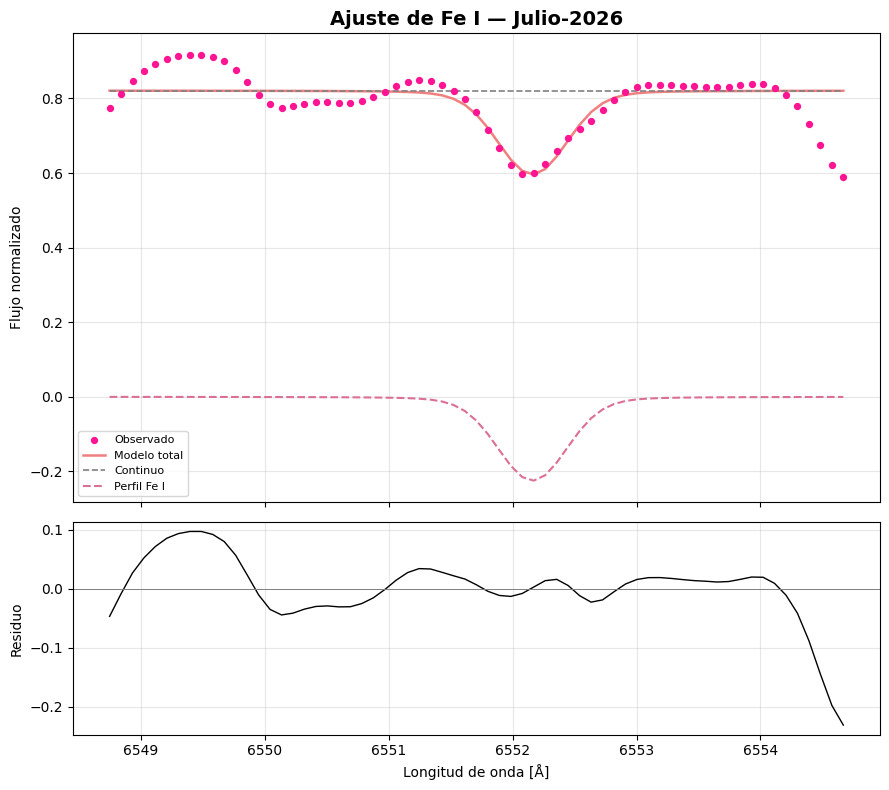

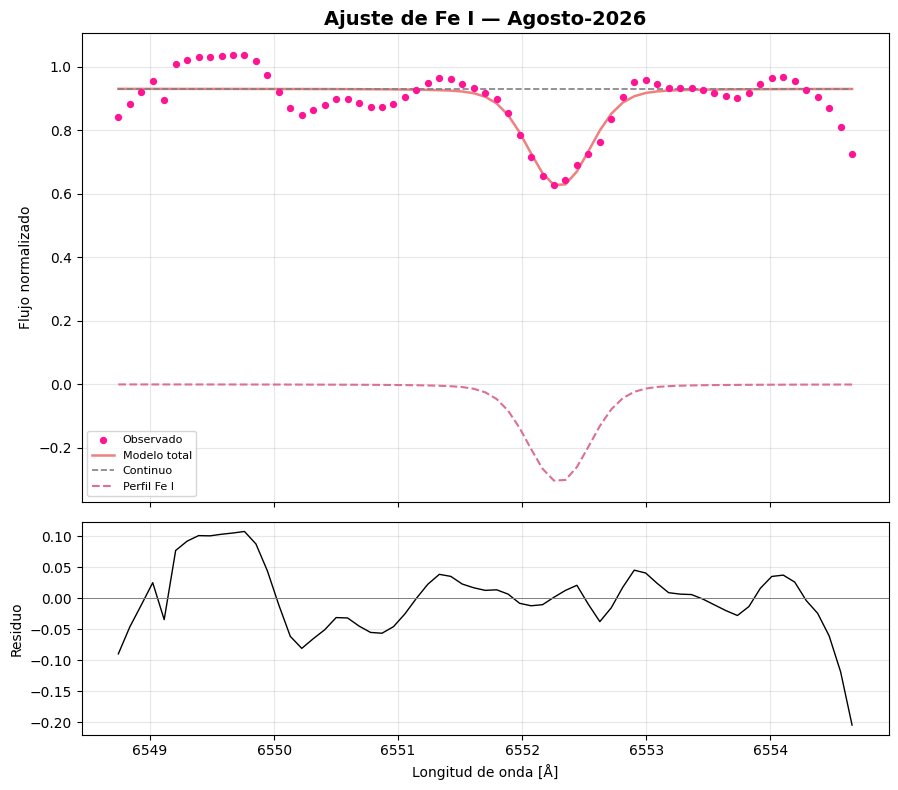

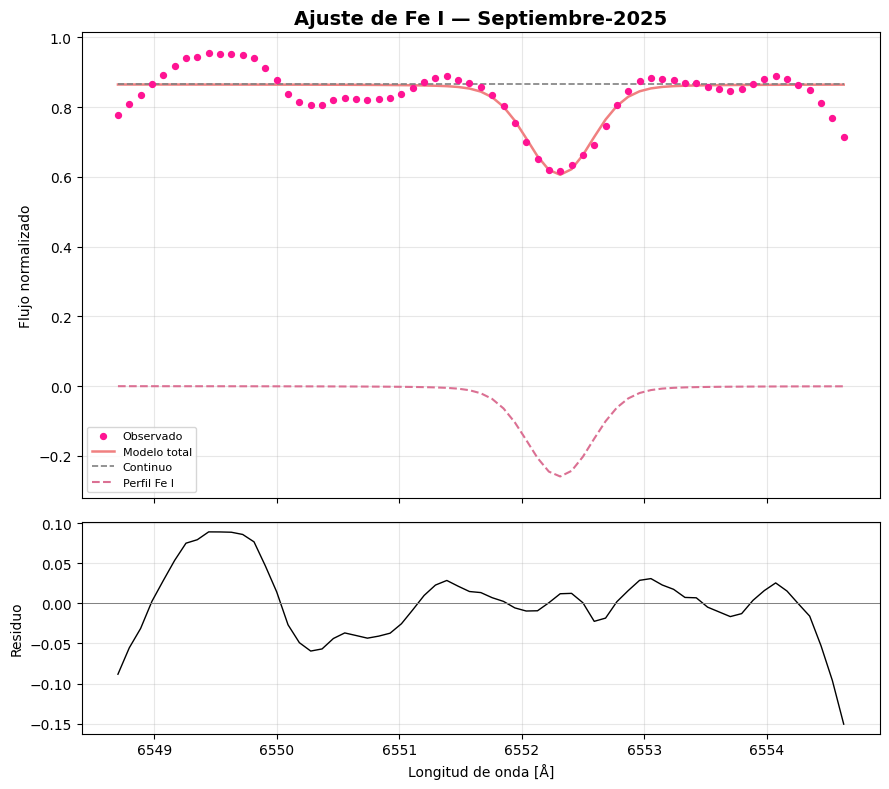

In [34]:
for fecha, res_fe in resultados_fe.items():
    visualizacion_fe(res_fe, fecha)

<h4 style="color: #e19edc;"> Resultados de los modelos para su análisis</sub></h4>

In [35]:
print("=" * 95)
print(
    f"{'FECHA':<18} | "
    f"{'PROFUNDIDAD Hα':<20} | "
    f"{'PROFUNDIDAD Co I':<20} | "
    f"{'PROFUNDIDAD Fe I':<20}"
)
print("=" * 95)

for fecha, res in resultados.items():

    fit = res["fit"]
    params = fit.params

    # Profundidades Hα y Co I
    prof_halpha = params["valle_abs_height"].value
    prof_cobalto = params["Cobalto_height"].value

    # Profundidad Fe I
    res_fe = resultados_fe[fecha]
    prof_fe = res_fe["profundidad_fit"]
    err_fe = res_fe["profundidad_err"]

    print(
        f"{fecha:<18} | "
        f"{abs(prof_halpha):<20.4f} | "
        f"{abs(prof_cobalto):<20.4f} | "
        f"{prof_fe:<10.4f} ± {err_fe:<7.4f}"
    )

print("=" * 95)

FECHA              | PROFUNDIDAD Hα       | PROFUNDIDAD Co I     | PROFUNDIDAD Fe I    
Julio-2026         | 0.7040               | 0.3432               | 0.2739     ± 0.0429 
Agosto-2026        | 1.0330               | 0.4175               | 0.3304     ± 0.0384 
Septiembre-2025    | 1.0973               | 0.3597               | 0.2996     ± 0.0327 
